# LLM prompting fundamentals: 
## One dataset, three prompts, three different results

---

### Why this notebook exists

A language model will write you syntactically perfect Python in ten seconds. That is no longer the difficult part.

The hard part is that **the model cannot see your data and has never met your patients.** It does not know that your 5,875 rows come from only 42 people. It does not know that one of your columns is an arbitrary ID rather than a measurement. It does not know that your outcome variable was interpolated between three clinic visits. It will nevertheless produce confident, well-formatted, plausible-looking code — built entirely on assumptions it invented on your behalf.

> **Core idea:** an LLM is highly capable but **context-starved**. Every fact you leave out of your prompt is replaced by the statistically most common fact from its training data. Sometimes that guess crashes. More often it does not.

### What you will do

You will attack the *same real dataset* three times, changing **nothing but the prompt**.

| Round | Prompt | What comes back | How it fails |
|---|---|---|---|
| **1** | One lazy sentence | Code for a *different dataset* that the model invented | **Loudly** — it crashes |
| **2** | Correct schema, nothing else | Clean code, `R² = 0.99`, a happy conclusion | **Silently** — it is scientifically worthless |
| **3** | Full specification | Honest evaluation, an unflattering number, a defensible claim | It does not |

Round 2 is the one that matters. Round 1 costs you thirty seconds. Round 2 costs you a paper.

### How to use this notebook

Keep a chat window open next to it — **any** model (Claude, ChatGPT, Gemini, Mistral, a local Llama…). For each round:

1. Run the prompt cell → **copy the printed prompt**
2. Paste it into your chat
3. Copy the code that comes back into the empty cell → **run it**

Your model will not answer exactly like mine. That is fine, and it is part of the lesson. Each round therefore gives you:

- a **"what to expect and why"** section *before* you run it — read it first, then check whether your model behaved as predicted;
- a **symptom checklist** to diagnose whatever your model actually produced;
- a **reference cell** reproducing the typical answer, so the notebook works end-to-end even if your model surprises you.

---

## Setup

Nothing exotic: `numpy`, `pandas`, `matplotlib`, `scikit-learn`. Printing versions is not decorationit is the cheapest reproducibility insurance there is, and it is something you should routinely *ask the model to include*.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

print("python      ", sys.version.split()[0])
print("numpy       ", np.__version__)
print("pandas      ", pd.__version__)
print("matplotlib  ", __import__("matplotlib").__version__)
print("scikit-learn", sklearn.__version__)

RANDOM_SEED = 7
pd.set_option("display.width", 120)

python       3.12.13
numpy        2.0.2
pandas       2.2.2
matplotlib   3.10.0
scikit-learn 1.6.1


---

## 1. The dataset: Oxford Parkinson's Disease Telemonitoring

**UCI Machine Learning Repository, dataset #189** — Tsanas & Little (2009), CC BY 4.0.
<https://archive.ics.uci.edu/dataset/189/parkinsons+telemonitoring>

**The clinical problem.** The UPDRS (Unified Parkinson's Disease Rating Scale) is *the* standard measure of Parkinson's severity. Scoring it requires a neurologist, in a clinic, with the patient physically present. It is slow, expensive, and — because it depends on a human rater — somewhat subjective.

**The idea.** Parkinson's degrades speech very early: the voice becomes breathy, unstable in pitch and amplitude. If a cheap acoustic measurement taken from a microphone at home could stand in for a UPDRS score, you could monitor disease progression continuously instead of three times a year.

**The study.** 42 people with early-stage Parkinson's were given a telemonitoring device at home. Each recorded a sustained vowel /a/ roughly weekly for six months. From each recording, 16 acoustic dysphonia measures were extracted (jitter = cycle-to-cycle variation in pitch; shimmer = variation in amplitude; NHR/HNR = noise-to-harmonics ratios; RPDE, DFA, PPE = nonlinear signal-dynamics measures).

**The modelling task, as UCI states it:** predict `motor_UPDRS` and `total_UPDRS` from the 16 voice measures.

Let's load it.

In [9]:
from pathlib import Path

from pandas.core.dtypes import dtypes

CACHE = Path("parkinsons_updrs.csv")

def load_telemonitoring() -> pd.DataFrame:
    """Load the UCI Parkinson's Telemonitoring dataset, with fallbacks.

    Tries, in order: a local cached CSV, the `ucimlrepo` package, then the
    UCI archive URL. Caches to disk so the notebook runs offline afterwards.
    """
    if CACHE.exists():
        return pd.read_csv(CACHE)

    try:                                    # official UCI python package
        from ucimlrepo import fetch_ucirepo
        data = fetch_ucirepo(id=189).data
        frame = data.original if data.original is not None else pd.concat(
            [data.features, data.targets], axis=1)
        frame.to_csv(CACHE, index=False)
        return frame
    except Exception as err:
        print(f"ucimlrepo unavailable ({type(err).__name__}), trying direct download…")

    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
           "parkinsons/telemonitoring/parkinsons_updrs.data")
    frame = pd.read_csv(url)
    frame.to_csv(CACHE, index=False)
    return frame


df = load_telemonitoring()
print("Rows:", df.shape[0], "Columns :", df.shape[1], "\n")
df.head()

Rows: 5875 Columns : 22 



,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


In [13]:
print("Columns types:", df.dtypes.to_string(), "\n")
df[["age", "sex", "test_time", "motor_UPDRS", "total_UPDRS"]].describe().round(2)

Columns types: subject#           int64
age                int64
sex                int64
test_time        float64
motor_UPDRS      float64
total_UPDRS      float64
Jitter(%)        float64
Jitter(Abs)      float64
Jitter:RAP       float64
Jitter:PPQ5      float64
Jitter:DDP       float64
Shimmer          float64
Shimmer(dB)      float64
Shimmer:APQ3     float64
Shimmer:APQ5     float64
Shimmer:APQ11    float64
Shimmer:DDA      float64
NHR              float64
HNR              float64
RPDE             float64
DFA              float64
PPE              float64 



,age,sex,test_time,motor_UPDRS,total_UPDRS
count,5875.00,5875.00,5875.00,5875.00,5875.00
mean,64.80,0.32,92.86,21.30,29.02
std,8.82,0.47,53.45,8.13,10.70
min,36.00,0.00,-4.26,5.04,7.00
25%,58.00,0.00,46.85,15.00,21.37
50%,65.00,0.00,91.52,20.87,27.58
75%,72.00,1.00,138.44,27.60,36.40
max,85.00,1.00,215.49,39.51,54.99


### Now: the five facts the file does **not** contain

Everything above is what an LLM would see if you pasted `df.head()` and `df.dtypes` into a chat. Here is what is *not* in there — and every single one of these changes the correct analysis:

1. 🧍 **5,875 rows are not 5,875 people. They are 42 people.** Each patient contributed 101–168 recordings. The rows are *nested inside subjects*, and rows from the same subject are heavily correlated.
2. 🔑 **`subject#` is an identifier, not a quantity.** Patient 17 is not "one more than" patient 16. It is stored as `int64`, so every library on earth will happily treat it as a number.
3. 📈 **`motor_UPDRS` and `total_UPDRS` were linearly interpolated.** The clinicians scored each patient only at baseline, 3 months and 6 months. Every other value in those columns was *drawn along a straight line between those visits*. So within a patient, UPDRS is very nearly a deterministic function of `test_time` — which makes `test_time` radioactive as a predictor.
4. ⚧ **`sex` is coded `0` = male, `1` = female.** Nothing in the file says so. A model may equally well assume the reverse, or treat it as ordinal.
5. ⏱️ **`test_time` is in days since recruitment, and some values are negative** (screening sessions before the official start date). The fractional part encodes the time of day. A model told only `float64` may reasonably decide negative values are corrupt and drop them.

Point 1 also settles the *scientific question*, which is the thing that ultimately determines whether an analysis is right or wrong. The clinical promise of telemonitoring is: **"hand this device to a patient we have never recorded before, and read off their severity."** That means the model must generalise **to new people** — not to new recordings from people it has already memorised.

Let us confirm point 1 numerically, because it drives everything downstream.

In [15]:
n_rows, n_subjects = len(df), df["subject#"].nunique()
per_subject = df.groupby("subject#").size()

print(f"{n_rows} recordings from {n_subjects} subjects")
print(f"recordings per subject: min={per_subject.min()}, median={int(per_subject.median())}, max={per_subject.max()}\n")

# How much of the variation in total_UPDRS is 'which patient is this?'
grp = df.groupby("subject#")["total_UPDRS"]
print(f"SD of total_UPDRS overall                : {df.total_UPDRS.std():.2f} points")
print(f"SD *between* subjects (of subject means) : {grp.mean().std():.2f} points")
print(f"SD *within* a subject (mean over subjects): {grp.std().mean():.2f} points\n")

print("=> Almost all the variance in the outcome is WHO the patient is,")
print("   not how that patient changed over six months.")

5875 recordings from 42 subjects
recordings per subject: min=101, median=141, max=168

SD of total_UPDRS overall                : 10.70 points
SD *between* subjects (of subject means) : 10.44 points
SD *within* a subject (mean over subjects): 2.51 points

=> Almost all the variance in the outcome is WHO the patient is,
   not how that patient changed over six months.


Hold on to that last block. **Roughly 95% of the variance in `total_UPDRS` is between-patient variance.** Any procedure that lets a model peek at a patient's UPDRS level in training and then quizzes it on that same patient in testing is not measuring prediction. It is measuring recall.

That single sentence is the whole notebook.

---

## Round 1 : The lazy prompt 

This is a general example of a vague prompt asking the LLM to guess what is expected as an outcome while providing minimal information and context.

In [16]:
PROMPT_1 = """
I have some voice recordings dataset from Parkinson's patients.
Write Python code to predict Parkinson's disease from it.
"""

print(PROMPT_1)


I have some voice recordings dataset from Parkinson's patients.
Write Python code to predict Parkinson's disease from it.



### What to expect and the why

Before you paste anything, predict the answer. A language model does not retrieve your file; it produces the **most probable continuation** of your words. So ask yourself: in the millions of notebooks, blog posts and web pages the model has seen in its training data, what usually follows the phrase *"the Parkinson's dataset from UCI"*?

Not this dataset. It follows the **other** one: *Oxford Parkinson's Disease Detection* (UCI #174), a 195-row table of 31 people used to classify **healthy vs. Parkinson's** via a column called `status`. That dataset is in every tutorial. Ours is not. "Predict Parkinson's disease" reinforces the wrong prior even harder, because it sounds like classification.

So expect the model to hallucinate a coherent, confident, *completely inapplicable* analysis:

- **an invented file path** — `pd.read_csv("parkinsons.csv")` or `"parkinsons.data"`, a file that is not on your disk;
- **an invented target column** — `y = df["status"]`, which does not exist here. It *cannot* exist here: all 42 people in this study have Parkinson's. There are no controls. The question "does this person have Parkinson's?" is unanswerable with this data;
- **invented feature names** — `MDVP:Fo(Hz)`, `MDVP:Jitter(%)`, `MDVP:Shimmer`. Ours are `Jitter(%)`, `Shimmer`, without the `MDVP:` prefix;
- **the wrong task family** — a `RandomForestClassifier` and an accuracy score, for what is actually a regression problem;
- **no mention of the 42 subjects**, because nothing in your sentence hinted that the rows were nested.

**Why this is guaranteed, not bad luck:** you asked a question whose answer depends on information that exists only on your hard drive. The model has two options — say "I don't know your columns" or produce the most likely-looking columns. Models are trained to be helpful, so most of them produce the columns. The confident tone is not evidence of confidence; it is the default register.

**IMPORTANT NOTE** : Some models are better calibrated and will *ask you* which Parkinson's dataset you mean, or will hedge with "assuming your file has a `status` column…". If yours does, note it — that is a genuinely useful property of your tool, and it is worth knowing which of your models behaves that way.

**Copy `PROMPT_1` into your chat window, then paste the code you get back into the cell below and run it.**

In [ ]:
# Copy the resulting

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load the Dataset
# We can load it directly from the UCI Machine Learning Repository URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/parkinsons.data"
print("Loading dataset...")
df = pd.read_csv(url)

# 2. Data Preprocessing
# The 'name' column is just a patient identifier and is not useful for prediction.
# The 'status' column is our target variable (1 = Parkinson's, 0 = Healthy).
X = df.drop(columns=['name', 'status'])
y = df['status']

print(len(X))

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
# Standardizing the features ensures that larger numerical values don't dominate the model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Train the Model
print("Training the Random Forest model...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# 4. Make Predictions
y_pred = model.predict(X_test_scaled)

# 5. Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy * 100:.2f}%\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Optional: Display the most important features
print("\n--- Top 5 Most Important Voice Features ---")
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
print(feature_importances.nlargest(5))

Loading dataset...
195
Training the Random Forest model...

--- Model Evaluation ---
Accuracy: 94.87%

Confusion Matrix:
[[ 5  2]
 [ 0 32]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.71      0.83         7
           1       0.94      1.00      0.97        32

    accuracy                           0.95        39
   macro avg       0.97      0.86      0.90        39
weighted avg       0.95      0.95      0.95        39


--- Top 5 Most Important Voice Features ---
PPE             0.141948
MDVP:Fo(Hz)     0.103600
spread1         0.100603
MDVP:Flo(Hz)    0.079445
Jitter:DDP      0.062098
dtype: float64


#### Symptom checklist — tick what your model produced

- [ ] It referenced a **file it has never seen** (`parkinsons.csv`, `data.csv`, a Kaggle path…)
- [ ] It used a column called **`status`**, or any column absent from `df.columns`
- [ ] It used **`MDVP:`**-prefixed feature names
- [ ] It built a **classifier** rather than a regressor
- [ ] It reported an **expected accuracy** (~90%) it could not possibly know
- [ ] It never asked how many **subjects** the rows came from

Any tick is a hallucination: content generated to fill a gap in your prompt, presented with the same fluency as content the model actually knows.

In [18]:
# ---- REFERENCE: the kind of code Prompt 1 typically produces ----
# Run it to watch the failure. The try/except is only so the notebook keeps going.

reference_round1 = """
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df.drop(columns=["name", "status"])   # <- hallucinated columns
y = df["status"]                          # <- hallucinated target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)
print("Accuracy:", accuracy_score(y_test, model.predict(X_test)))
"""

try:
    exec(reference_round1)
except KeyError as err:
    print(f"KeyError: {err}")
    print()
    print("The model asked for a column that does not exist in this dataset.")
    print("Columns actually available:")
    print("  ", ", ".join(df.columns))

Accuracy: 0.9487179487179487


### A **loud** failure

The code never ran. You lost a little time and know that something is wrong with the provided code.

The model did nothing irrational: it received an under-specified request and returned the highest-probability completion. Given the words you typed, code for UCI #174 *was* the highest-probability completion.

**And this is the least armful failure mode.** An exception is a gift: it is unambiguous, immediate, and impossible to publish. Let's fix the obvious problem — and meet the failure mode that is not harmless.

---

## 3. Round 2 : The "reasonable" prompt

Round 1 failed because the model didn't know the specific of your dataset. So give it your columns. This is what a careful student does on the second try, and it is a real improvement — the code will run this time.

First, generate the schema dump you are going to paste. (This is a genuinely useful habit: never *describe* your dataframe from memory, print it.)

In [15]:
schema = "\n".join(f"  {c:<14} {t}" for c, t in df.dtypes.items())

PROMPT_2 = f"""
I have a pandas DataFrame `df` from the UCI Parkinson's Telemonitoring dataset.
Shape: {df.shape}. Columns and dtypes:

{schema}

First 3 rows:
{df.head(3).to_string()}

Build a machine learning model that predicts total_UPDRS.
Split the data into train and test sets, report the performance,
and plot predicted vs actual values.
"""

print(PROMPT_2)


I have a pandas DataFrame `df` from the UCI Parkinson's Telemonitoring dataset.
Shape: (195, 24). Columns and dtypes:

  name           object
  MDVP:Fo(Hz)    float64
  MDVP:Fhi(Hz)   float64
  MDVP:Flo(Hz)   float64
  MDVP:Jitter(%) float64
  MDVP:Jitter(Abs) float64
  MDVP:RAP       float64
  MDVP:PPQ       float64
  Jitter:DDP     float64
  MDVP:Shimmer   float64
  MDVP:Shimmer(dB) float64
  Shimmer:APQ3   float64
  Shimmer:APQ5   float64
  MDVP:APQ       float64
  Shimmer:DDA    float64
  NHR            float64
  HNR            float64
  status         int64
  RPDE           float64
  DFA            float64
  spread1        float64
  spread2        float64
  D2             float64
  PPE            float64

First 3 rows:
             name  MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  MDVP:Shimmer(dB)  Shimmer:APQ3  Shimmer:APQ5  MDVP:APQ  Shimmer:DDA      NHR     HNR  status      RPDE       DFA   spread1  

### What to expect — and *why* 🔮

Everything in that prompt is **true**. Nothing in it is *sufficient*. The schema tells the model what the columns are called and what type they hold. It says nothing about what they *mean*, and nothing at all about how the rows relate to each other.

So the model falls back — again — on the most probable continuation. And the most probable continuation of "here are my columns, build a model, split train/test, report performance" is the canonical supervised-learning tutorial, which every model has seen tens of thousands of times:

```python
X = df.drop(columns=[target])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor().fit(X_train, y_train)
print("R²:", r2_score(y_test, model.predict(X_test)))
```

Expect specifically:

- **`train_test_split` with a random shuffle.** This is the default in every tutorial, and it is the fatal choice here.
- **`subject#` kept as a feature**, or dropped only if the model happens to notice the `#` — treatment varies a lot between models, which is exactly why you cannot rely on it.
- **`test_time` kept as a feature.** It looks like a perfectly ordinary float.
- **A tree ensemble**, because that is the default reflex for tabular data.
- **An excellent score** — anywhere from `R² ≈ 0.35` to `R² ≈ 0.99` depending on which columns it kept.
- **A confident closing sentence** along the lines of *"the model explains 99% of the variance in disease severity."*

**Why the model cannot avoid this.** The catastrophic fact — *5,875 rows, 42 people* — is invisible in everything you gave it. It is not in the column names. It is not in the dtypes. It is not in `df.head(3)`, which shows three rows that all happen to be patient 1 but gives no indication that ~140 more of them follow. A model would have to *guess* that your rows are nested, and guessing conservatively is not what these systems do.

⚠️ **Your number will differ from mine and from your neighbour's**, because it depends on whether your model dropped `subject#` and `test_time`. Both variants are shown in the reference cell below. **Both are wrong.** Only the size of the lie changes.

👉 **Copy `PROMPT_2` into your chat, paste the answer below, run it. Write down the score before reading on.**

MAE : 2.158
RMSE: 2.970
R²  : 0.920


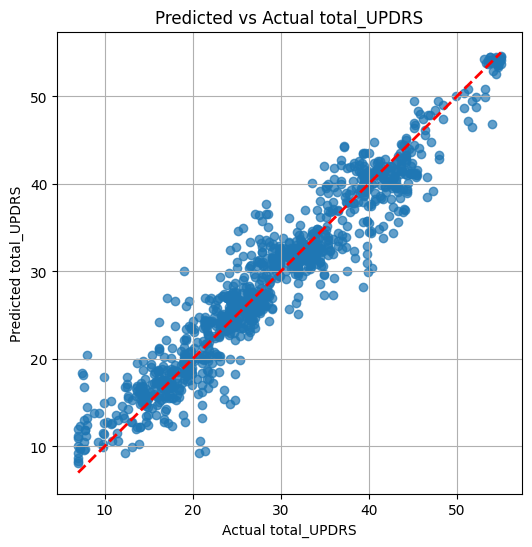

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
# df = pd.read_csv(url)
# ---------------------------------------
# Target
# ---------------------------------------
target = "total_UPDRS"

# Remove identifiers if present
drop_cols = [target]

if "motor_UPDRS" in df.columns:
    drop_cols.append("motor_UPDRS")  # avoid leakage if predicting total_UPDRS

if "subject#" in df.columns:
    drop_cols.append("subject#")

if "test_time" in df.columns:
    drop_cols.append("test_time")

X = df.drop(columns=drop_cols)
y = df[target]

# One-hot encode categorical variables (e.g., sex)
X = pd.get_dummies(X, drop_first=True)

# ---------------------------------------
# Train/Test split
# ---------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

# ---------------------------------------
# Model
# ---------------------------------------
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

model.fit(X_train, y_train)

# ---------------------------------------
# Predictions
# ---------------------------------------
y_pred = model.predict(X_test)

# ---------------------------------------
# Metrics
# ---------------------------------------
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²  : {r2:.3f}")

# ---------------------------------------
# Predicted vs Actual
# ---------------------------------------
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)

mn = min(y_test.min(), y_pred.min())
mx = max(y_test.max(), y_pred.max())

plt.plot([mn, mx], [mn, mx], "r--", lw=2)

plt.xlabel("Actual total_UPDRS")
plt.ylabel("Predicted total_UPDRS")
plt.title("Predicted vs Actual total_UPDRS")
plt.grid(True)

plt.show()

#### Symptom checklist — tick what your model produced

- [ ] It used **`train_test_split`** with the default shuffle (no `groups=`, no `GroupKFold`)
- [ ] It kept **`subject#`** among the predictors
- [ ] It kept **`test_time`** among the predictors
- [ ] It reported **one** score from **one** split (no cross-validation, no spread)
- [ ] It compared the score to **nothing** — no baseline, no "predict the mean" reference
- [ ] Its conclusion was **about disease severity**, not about the model
- [ ] Nowhere does the word **subject / patient / participant** appear in its reasoning

Zero errors were raised. Every box you ticked is still a defect.

A) all columns kept (incl. subject#)       R2 =  0.999   MAE =  0.15 UPDRS points
B) only the 16 voice measures              R2 =  0.358   MAE =  6.50 UPDRS points


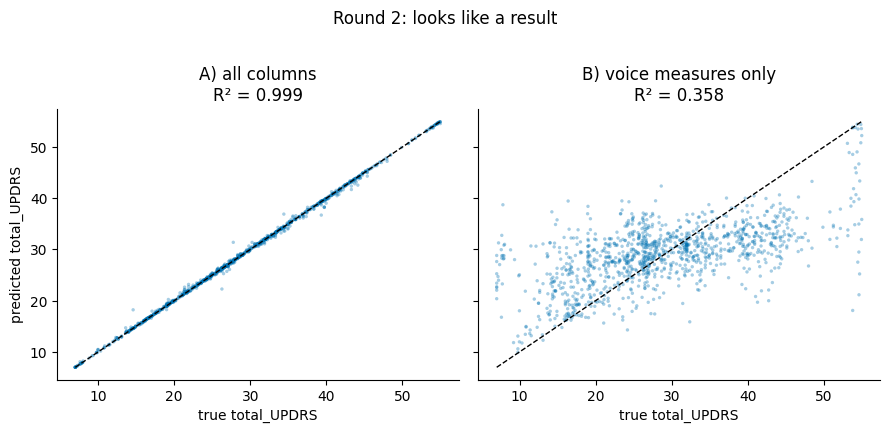

In [23]:
# ---- REFERENCE: the two answers Prompt 2 typically produces ----
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

VOICE = [c for c in df.columns
         if c not in ["subject#", "age", "sex", "test_time", "motor_UPDRS", "total_UPDRS"]]
y = df["total_UPDRS"]


def naive_split_model(X, y, label):
    """The canonical tutorial pipeline: random split, fit, score."""
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1).fit(X_tr, y_tr)
    pred = model.predict(X_te)
    print(f"{label:<42} R2 = {r2_score(y_te, pred):6.3f}   "
          f"MAE = {mean_absolute_error(y_te, pred):5.2f} UPDRS points")
    return pred, y_te


# Variant A: model keeps everything except the two targets
pred_a, true_a = naive_split_model(df.drop(columns=["motor_UPDRS", "total_UPDRS"]), y,
                                   "A) all columns kept (incl. subject#)")

# Variant B: model is a bit smarter and uses only the 16 voice measures
pred_b, true_b = naive_split_model(df[VOICE], y,
                                   "B) only the 16 voice measures")

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2), sharex=True, sharey=True)
for ax, (p, t, title) in zip(axes, [(pred_a, true_a, "A) all columns"),
                                    (pred_b, true_b, "B) voice measures only")]):
    ax.scatter(t, p, s=6, alpha=0.35, color="#0072B2", edgecolors="none")
    lims = [df.total_UPDRS.min(), df.total_UPDRS.max()]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_xlabel("true total_UPDRS")
    ax.set_title(f"{title}\nR² = {r2_score(t, p):.3f}")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("predicted total_UPDRS")
fig.suptitle("Round 2: looks like a result", y=1.02)
plt.tight_layout()
plt.show()

### Diagnosis — a **silent** failure 🔇

Look at panel A. The points sit on the diagonal. `R² = 0.999`, mean absolute error **0.15 UPDRS points** — a clinician re-scoring the same patient twice would not agree with themselves that closely. Panel B is less spectacular but far more dangerous: `R² ≈ 0.35` is *exactly* the kind of number that gets written up as "moderate but promising predictive performance."

No exception. No warning. A figure you could drop into a slide deck this afternoon.

**Both panels are scientifically meaningless.** Three compounding reasons, none of which the model could have inferred:

**a) Subject leakage — the core error.** `train_test_split` shuffles rows. Each patient contributed ~140 recordings, so about 112 of any patient's recordings land in *train* and about 28 land in *test*. The model therefore sees every single test patient during training, along with their UPDRS score. Since ~95% of the variance in UPDRS is between-patient (you computed this in section 1), a model can score brilliantly by learning nothing but *"this voice sounds like patient 23, and patient 23 sits at 32 UPDRS points."* That is voice **identification**, not severity **estimation**. The clinical claim — "give it a new patient" — is never tested.

**b) `subject#` as a predictor (panel A).** The patient ID goes straight into the forest as an integer. Combined with `test_time`, it is close to a lookup key.

**c) `test_time` plus interpolation (panel A).** Remember fact 3: UPDRS was linearly interpolated between three clinic visits. So within a patient, UPDRS is nearly a *straight-line function of time*. Handing the model `(subject#, test_time)` is handing it the two coordinates of that line. It is not predicting disease progression; it is inverting an interpolation formula. Hence `R² = 0.999`.

Let's prove (a) directly, because it is the claim students find hardest to believe.

In [ ]:
# Proof of leakage: how much of the 'skill' is just recognising the patient?
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

id_accuracy = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    df[VOICE], df["subject#"], cv=3, scoring="accuracy").mean()

print(f"Predicting WHICH PATIENT a recording came from, using only the 16 voice measures")
print(f"  accuracy               : {id_accuracy:.1%}")
print(f"  chance level (1 of 42) : {1 / df['subject#'].nunique():.1%}")
print()
print(f"The voice features carry ~{id_accuracy / (1 / 42):.0f}x more information about")
print("patient identity than chance. Under a random split, that is all a model needs.")

Twenty times chance. The acoustic measures are a **voiceprint**. Under a random split, a "severity model" can reach a strong score purely by identifying the speaker and recalling that speaker's typical score — and it will, because that is the easiest available path to a low training loss.

The model could not have known any of this. **You could.** That asymmetry is the entire lesson.

---

## 4. Anatomy of a good prompt

A prompt for research code is a **specification**, not a wish. Six blocks, always the same ones:

| Block | What it answers | What it would have fixed here |
|---|---|---|
| **1. Role & environment** | Who is writing, which libraries, what deliverable | Stops imports you don't have; sets the standard of rigour |
| **2. Data contract** | Exact columns, dtypes, **units**, ranges, encodings, sentinels | Kills the `status` hallucination; declares `sex` 0/1 and negative `test_time` |
| **3. Domain constraints** | What the numbers *mean*, which are IDs, how the outcome was measured | Kills `subject#`-as-feature and the interpolation leak |
| **4. Design & unit of generalisation** | Nesting, repeated measures, **what the model must generalise to** | Kills subject leakage — the error that broke Round 2 |
| **5. Output specification** | Exact metrics, baselines, figure layout, labels | Gets you a number you can compare to something |
| **6. Validation & reproducibility** | Seeds, assertions, printed counts, docstrings | Lets you *prove* the result six months later |

Two things are worth noticing about that table.

**Block 4 is the one everybody omits, and it is the one that decides whether the analysis is science.** "What must this model generalise to?" is not a machine-learning question. It is a question about your experiment. Answer *new patients* and you must split by patient. Answer *future recordings from these same patients* and a random split is defensible — a different, narrower, still-publishable claim. The data cannot tell you which; only you can.

**Almost none of these blocks require you to know Python.** They require you to know your study. That is precisely the part you cannot outsource — and precisely the part that a fluent, confident-sounding answer will tempt you into thinking you already did.

---

## 5. Round 3 — the specified prompt ✅

Now we write the six blocks. Notice how much of it is neurology and study design, and how little of it is code.

In [ ]:
PROMPT_3 = """
=== 1. ROLE & ENVIRONMENT ===
You are helping analyse a clinical dataset for a peer-reviewed publication in a
biomedical journal. Use Python 3 with only numpy, pandas, matplotlib and
scikit-learn. Return ONE self-contained, runnable code cell. Use functions with
docstrings. Do not invent or simulate data. If something in this specification is
ambiguous, state the assumption you made in a comment rather than hiding it.

=== 2. DATA CONTRACT ===
A pandas DataFrame `df` is already loaded: the UCI Parkinson's Telemonitoring
dataset (Tsanas & Little, 2009), 5875 rows x 22 columns, no missing values.

  subject#      int64    Patient IDENTIFIER, 1..42. Categorical, NOT a quantity.
  age           int64    Years, 36..85. Constant within a patient.
  sex           int64    0 = male, 1 = female. Constant within a patient.
  test_time     float64  Days since recruitment, -4.26..215.5. May be negative
                         (pre-enrolment screening). Fractional part = time of day.
  motor_UPDRS   float64  Clinician's motor UPDRS, 5.0..39.5.  <- see constraint C3
  total_UPDRS   float64  Clinician's total UPDRS, 7.0..55.0.  <- TARGET
  16 further float64 columns, the acoustic dysphonia measures:
    Jitter(%), Jitter(Abs), Jitter:RAP, Jitter:PPQ5, Jitter:DDP,
    Shimmer, Shimmer(dB), Shimmer:APQ3, Shimmer:APQ5, Shimmer:APQ11, Shimmer:DDA,
    NHR, HNR, RPDE, DFA, PPE
  Column names contain '#', '%', '(', ')' and ':' - index with df["..."], never
  with attribute access.

=== 3. DOMAIN CONSTRAINTS ===
C1. Every one of the 42 patients has Parkinson's disease. There are no healthy
    controls. Diagnosis is NOT a possible target; this is a regression problem.
C2. subject# must NEVER be used as a predictor. It is an arbitrary label.
    age and sex must also be excluded: they are constant within a patient, so
    including them lets the model identify patients rather than measure severity.
C3. motor_UPDRS and total_UPDRS are two scorings of the same clinical exam.
    Using one to predict the other is circular. Exclude motor_UPDRS entirely.
C4. Both UPDRS columns were LINEARLY INTERPOLATED between only three clinician
    visits (baseline, 3 months, 6 months). Within a patient the target is
    therefore close to a straight-line function of test_time. test_time must NOT
    be used as a predictor: it would invert the interpolation, not predict biology.
C5. Predictors are exactly the 16 acoustic measures listed above, nothing else.
    They live on very different scales (Jitter(Abs) ~ 1e-5, HNR ~ 20), so any
    scale-sensitive model must be wrapped in a pipeline with StandardScaler.

=== 4. DESIGN & UNIT OF GENERALISATION ===
D1. Repeated-measures design: 42 patients contributed 101-168 recordings each.
    Recordings from one patient are NOT independent observations.
D2. The clinical claim to be tested is: "given a patient this system has never
    recorded before, can we estimate their UPDRS from their voice?"
    The unit of generalisation is therefore the PATIENT, not the recording.
D3. Consequently: use GroupKFold (5 folds) with groups=df["subject#"] so that
    no patient ever appears in both a training fold and its test fold.
    Do NOT use train_test_split, KFold or ShuffleSplit anywhere.
D4. Report the score of each fold separately as well as the mean. Fold-to-fold
    spread across only 42 patients is itself a result.

=== 5. OUTPUT SPECIFICATION ===
O1. Evaluate two models under the identical GroupKFold splits:
      - a RandomForestRegressor (100 trees, fixed random_state)
      - a DummyRegressor(strategy="mean") as the mandatory floor: it predicts the
        training-fold mean UPDRS and ignores the voice entirely.
O2. Metrics: mean absolute error in UPDRS points (primary, because it is
    clinically interpretable) and R^2 (secondary). Report both as
    "mean +/- SD across folds". Explain in a comment that a negative R^2 means
    the model is worse than predicting the mean.
O3. For scale: clinically meaningful change on the total UPDRS is a few points.
    State the MAE against that yardstick.
O4. One figure, two panels, figsize about (10, 4.2):
      - Left: per-fold MAE for both models, side by side, so the reader sees the
        model against its floor fold by fold.
      - Right: out-of-fold predicted vs true total_UPDRS (use cross_val_predict
        with the same GroupKFold), with the identity line, plus a horizontal line
        at the overall mean UPDRS.
      Axis labels must state units (UPDRS points). Colourblind-safe colours,
      no top/right spines.
O5. Print a plain-language conclusion of at most four sentences: what was
    compared, on how many patients, whether the voice measures beat the floor,
    and what may NOT be concluded from this result.

=== 6. VALIDATION & REPRODUCIBILITY ===
V1. assert that no patient appears in both sides of any split.
V2. assert that the predictor list contains exactly 16 columns and includes none
    of: subject#, age, sex, test_time, motor_UPDRS, total_UPDRS.
V3. Print the number of patients and recordings entering the analysis, and the
    number of test patients in each fold.
V4. Fix every random_state. Derive all numbers from `df`; hard-code nothing.
"""

print(PROMPT_3)

### What to expect — and *why* 🔮

**Expect a much worse number. That is the point.**

Now that the prompt names the grouping variable, the excluded columns and the comparison floor, the model has almost no room to substitute a guess. It has stopped choosing the analysis. You have.

Concretely, expect:

- `GroupKFold(n_splits=5)` with `groups=df["subject#"]`, and no `train_test_split` anywhere;
- exactly 16 predictors, `subject#` / `age` / `sex` / `test_time` / `motor_UPDRS` all gone;
- a random forest whose **MAE is around 9–10 UPDRS points**;
- a dummy baseline whose **MAE is around 8.9 UPDRS points**;
- an **R² near zero or negative** — around −0.4 for the forest;
- wide fold-to-fold spread, because each fold tests only 8–9 patients;
- a conclusion that says, in effect, *the voice measures do not beat the mean.*

**Why the honest answer is so bad, mechanistically.** Under a grouped split the model is tested on patients whose UPDRS level it has never seen. The between-patient variation it exploited in Round 2 is now precisely what it must predict — and 16 acoustic measures from a sustained vowel, on 42 people, do not carry that signal. The forest ends up doing *worse than predicting the mean*, which is what a negative R² means: it uses voice features to move its predictions away from the group average in the wrong direction.

Round 2 said `R² = 0.999`. Round 3 says `R² ≈ −0.4`. **Same data, same library, same afternoon.** The 0.999 was measuring how well a model can recognise a voice it has already heard.

**This is a real result, not a broken one.** "16 dysphonia measures do not generalise to unseen patients in a 42-person cohort" is a finding — it is informative, it is defensible under review, and it points somewhere: the telemonitoring literature works with *within-patient change over time* and *personalised, per-patient calibration*, not with a single population model. A negative result you can trust beats a positive one you cannot.

⚠️ **Expect variation across models here too**, but of a different kind. With a specification this tight, models diverge on *presentation* — how they arrange the figure, whether they add an extra metric — not on *methodology*. Compare your model's output to the reference below: the numbers should be close. If your MAE is dramatically better than ~9 points, something leaked; go find it. **That check is a skill, and it is why Block 6 exists.**

👉 **Copy `PROMPT_3` into your chat, paste the answer below, run it.**

In [ ]:
# ⬇️⬇️⬇️  PASTE THE LLM ANSWER FOR PROMPT 3 HERE, THEN RUN  ⬇️⬇️⬇️

In [ ]:
# ---- REFERENCE: the kind of code Prompt 3 typically produces ----
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import GroupKFold, cross_validate, cross_val_predict

TARGET = "total_UPDRS"
EXCLUDED = ["subject#", "age", "sex", "test_time", "motor_UPDRS", "total_UPDRS"]
PREDICTORS = [c for c in df.columns if c not in EXCLUDED]

# --- V2: the predictor set is what we claim it is ---
assert len(PREDICTORS) == 16, f"expected 16 acoustic predictors, got {len(PREDICTORS)}"
assert not set(PREDICTORS) & set(EXCLUDED), "an excluded column leaked into the predictors"

X, y_true, groups = df[PREDICTORS], df[TARGET], df["subject#"]
cv = GroupKFold(n_splits=5)

# --- V1/V3: no patient may appear on both sides of a split ---
print(f"{len(df)} recordings from {groups.nunique()} patients\n")
for k, (tr, te) in enumerate(cv.split(X, y_true, groups), start=1):
    train_ids, test_ids = set(groups.iloc[tr]), set(groups.iloc[te])
    assert not train_ids & test_ids, f"fold {k}: patient leakage!"
    print(f"  fold {k}: {len(train_ids)} train patients, {len(test_ids)} held-out patients")


def evaluate(model, name):
    """Score a model under patient-wise GroupKFold. Returns per-fold MAE and R^2."""
    scores = cross_validate(model, X, y_true, groups=groups, cv=cv,
                            scoring=["neg_mean_absolute_error", "r2"])
    mae, r2 = -scores["test_neg_mean_absolute_error"], scores["test_r2"]
    print(f"{name:<28} MAE = {mae.mean():5.2f} +/- {mae.std():.2f} UPDRS points   "
          f"R2 = {r2.mean():6.3f} +/- {r2.std():.3f}")
    return mae, r2


print("\n--- Patient-wise 5-fold cross-validation ---")
# A negative R^2 means the model does worse than simply predicting the mean.
mae_rf, r2_rf = evaluate(
    RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1),
    "Random forest (16 voice)")
mae_dummy, r2_dummy = evaluate(
    DummyRegressor(strategy="mean"), "Baseline: predict the mean")

# --- figure ---
oof = cross_val_predict(
    RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1),
    X, y_true, groups=groups, cv=cv)

BLUE, ORANGE, GREY = "#0072B2", "#D55E00", "#8C8C8C"
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.2))

folds = np.arange(1, len(mae_rf) + 1)
ax1.bar(folds - 0.19, mae_rf, width=0.38, color=BLUE, label="random forest")
ax1.bar(folds + 0.19, mae_dummy, width=0.38, color=GREY, label="predict the mean")
ax1.set_xticks(folds)
ax1.set_xlabel("cross-validation fold (held-out patients)")
ax1.set_ylabel("mean absolute error (UPDRS points)")
ax1.set_title("The model against its floor, fold by fold")
ax1.legend(frameon=False, fontsize=9)

ax2.scatter(y_true, oof, s=6, alpha=0.30, color=BLUE, edgecolors="none")
lims = [y_true.min(), y_true.max()]
ax2.plot(lims, lims, "k--", lw=1, label="perfect prediction")
ax2.axhline(y_true.mean(), color=ORANGE, lw=1.5, ls=":", label="overall mean UPDRS")
ax2.set_xlabel("true total_UPDRS (points)")
ax2.set_ylabel("out-of-fold prediction (points)")
ax2.set_title(f"Held-out patients (R² = {r2_rf.mean():.2f})")
ax2.legend(frameon=False, fontsize=9, loc="upper left")

for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Round 3: what the voice measures actually deliver", y=1.02)
plt.tight_layout()
plt.show()

# --- O5: plain-language conclusion ---
verdict = "did NOT beat" if mae_rf.mean() >= mae_dummy.mean() else "beat"
print(f"""
CONCLUSION
Across 42 patients evaluated with patient-wise 5-fold cross-validation, a random
forest using the 16 acoustic dysphonia measures {verdict} the trivial baseline of
predicting the cohort mean ({mae_rf.mean():.2f} vs {mae_dummy.mean():.2f} UPDRS points of mean absolute
error). Since clinically meaningful change on the total UPDRS is a few points, an
error of ~{mae_rf.mean():.0f} points is not usable for individual severity estimation.
This does not show that voice is uninformative about Parkinson's: it shows that
these features do not transfer to unseen patients in a cohort of this size, which
is a different and much narrower claim.""")

### Diagnosis — a result you can defend 🛡️

The right-hand panel is the honest picture: a flat, shapeless cloud sitting near the cohort mean. The model has learned the group average and little else. The left-hand panel makes that unarguable — the grey bar is as low as the blue one in every fold.

Compare what the two figures let you say:

- **Round 2:** *"Acoustic measures predict Parkinson's severity with R² = 0.99."* — a false claim, with a beautiful figure.
- **Round 3:** *"In 42 patients, these acoustic measures did not estimate UPDRS in unseen patients better than the cohort mean."* — a true claim, with an unglamorous figure.

The Round 3 figure also carries its own audit trail: how many patients, how many held out per fold, which metric, which baseline, and the fold-to-fold spread instead of a single number that hides it. A reviewer can check every one of those. That is the difference between a result and a screenshot.

---

## 6. The three verdicts, side by side

Recomputed from scratch, so this section is valid whatever you pasted above.

In [ ]:
from sklearn.model_selection import cross_val_score

y_all = df["total_UPDRS"]
rf = lambda: RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)

# Round 2A: random split, every column kept
Xa = df.drop(columns=["motor_UPDRS", "total_UPDRS"])
a_tr, a_te, ya_tr, ya_te = train_test_split(Xa, y_all, test_size=0.2, random_state=42)
r2_a = r2_score(ya_te, rf().fit(a_tr, ya_tr).predict(a_te))
mae_a = mean_absolute_error(ya_te, rf().fit(a_tr, ya_tr).predict(a_te))

# Round 2B: random split, voice measures only
b_tr, b_te, yb_tr, yb_te = train_test_split(df[VOICE], y_all, test_size=0.2, random_state=42)
pred_b2 = rf().fit(b_tr, yb_tr).predict(b_te)
r2_b, mae_b = r2_score(yb_te, pred_b2), mean_absolute_error(yb_te, pred_b2)

# Round 3: patient-wise split, voice measures only
gcv = GroupKFold(n_splits=5)
r2_c = cross_val_score(rf(), df[VOICE], y_all, groups=df["subject#"], cv=gcv, scoring="r2").mean()
mae_c = -cross_val_score(rf(), df[VOICE], y_all, groups=df["subject#"], cv=gcv,
                         scoring="neg_mean_absolute_error").mean()

verdicts = pd.DataFrame({
    "prompt":      ["1 - lazy", "2A - schema only", "2B - schema only", "3 - specified"],
    "split":       ["-", "random rows", "random rows", "by patient"],
    "predictors":  ["-", "all 20 columns", "16 voice", "16 voice"],
    "generalises to": ["-", "seen patients", "seen patients", "NEW patients"],
    "R2":          [np.nan, r2_a, r2_b, r2_c],
    "MAE":         [np.nan, mae_a, mae_b, mae_c],
    "conclusion":  ["crashed: hallucinated columns",
                    "'explains 99.9% of severity'",
                    "'moderate predictive power'",
                    "'no better than the mean'"],
}).round({"R2": 3, "MAE": 2})

print(verdicts.to_string(index=False))

In [ ]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(10, 4.3), sharex=True, sharey=True)

oof3 = cross_val_predict(rf(), df[VOICE], y_all, groups=df["subject#"], cv=gcv)
lims = [y_all.min(), y_all.max()]

for ax, (t, p, title, sub) in zip(
    (axL, axR),
    [(ya_te, rf().fit(a_tr, ya_tr).predict(a_te),
      "WRONG - rows split at random", f"R² = {r2_a:.3f}  ->  'voice predicts severity'"),
     (y_all, oof3,
      "RIGHT - patients split", f"R² = {r2_c:.3f}  ->  'voice does not transfer'")]):
    ax.scatter(t, p, s=6, alpha=0.30, color="#0072B2", edgecolors="none")
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_xlabel("true total_UPDRS (points)")
    ax.set_title(f"{title}\n{sub}")
    ax.spines[["top", "right"]].set_visible(False)

axL.set_ylabel("predicted total_UPDRS (points)")
plt.tight_layout()
plt.show()

Same data. Same model class. Same fifteen lines of scikit-learn.

The only thing that changed between those two panels is **how much of your study you bothered to describe.**

---

## 7. What to take away

1. **The model is not wrong; it is uninformed.** It cannot see your file, your cohort, or your recruitment protocol. Every fact you omit is silently replaced by the most common pattern in its training data — and that substitution is invisible in the output, because fluent prose and broken analysis look identical.

2. **Loud failures are cheap; silent failures are the expensive ones.** `KeyError: 'status'` cost thirty seconds. `R² = 0.999` would have cost a manuscript, a reviewer's afternoon, and eventually a retraction.

3. **Ask "what must this generalise to?" before you ask for any code.** New patients? New sessions from the same patients? New sites? The answer dictates the split, and the split dictates whether the number means anything. This is the single most commonly omitted block, and the one that broke Round 2.

4. **Identifiers are not features.** `subject#` was an `int64`, so every tool treated it as a quantity. Anything constant within a subject — ID, age, sex, site, scanner — hands the model a shortcut to recognising the subject instead of measuring the outcome.

5. **Always demand a baseline.** `R² = 0.35` sounds like something. Against `DummyRegressor(strategy="mean")` it turned out to be nothing. A metric without a floor is not a result; it is a number.

6. **Know how your outcome was produced.** The UPDRS values were interpolated between three visits. No amount of Python could have recovered that from the column names, and it alone accounts for the difference between `R² = 0.999` and `R² = 0.35`.

7. **A good prompt is a methods section written in advance.** If you cannot write the prompt, you do not yet understand the analysis — and no model will understand it for you. Conversely, once you *can* write it, the model becomes genuinely excellent at the part it is good at: turning a clear specification into correct code, fast.

8. **You remain the author.** "The model wrote it" is not a defence at review, in a thesis committee, or in a correction notice. Read every generated line, and check that the numbers in the figure match the numbers in the printout.

### A reusable template

Keep this in a scratch file. Fill it in *before* you ask for code — the act of filling it in is most of the analysis.

In [ ]:
PROMPT_TEMPLATE = """
=== 1. ROLE & ENVIRONMENT ===
  Language and version, allowed libraries, deliverable format.
  Standard of rigour (exploratory sketch? publication-grade?).
  Instruction: state assumptions explicitly instead of hiding them.

=== 2. DATA CONTRACT ===
  Every column: name, dtype, UNITS, valid range, meaning.
  Encodings (0/1 for what?), missing-data convention (NaN? sentinel?).
  Exact shape. Awkward characters in column names.

=== 3. DOMAIN CONSTRAINTS ===
  Which columns are IDENTIFIERS and must never be predictors.
  Which columns are circular / derived from the target.
  How the outcome was actually measured (interpolated? averaged? rated by whom?).
  Exclusion criteria, plausibility bounds, known artefacts, scale differences.

=== 4. DESIGN & UNIT OF GENERALISATION ===
  Nesting: trials in sessions in subjects in sites.
  Repeated measures? Paired? Balanced?
  >>> WHAT MUST THE RESULT GENERALISE TO? <<<
  The splitting / grouping variable that follows from that answer.

=== 5. OUTPUT SPECIFICATION ===
  Primary and secondary metrics, and why they are interpretable.
  The BASELINE the result must be compared against.
  Effect sizes, uncertainty, per-fold or per-subject spread.
  Figure: panels, size, colours, axis labels WITH UNITS, what error bars mean.
  A plain-language conclusion, including what may NOT be concluded.

=== 6. VALIDATION & REPRODUCIBILITY ===
  Assertions that would catch the failure you most fear.
  Counts to print, seeds to fix, edge cases to handle.
  Docstrings, no hard-coded numbers, library versions.
"""

print(PROMPT_TEMPLATE)

---

### Data citation

Tsanas, A. & Little, M. (2009). *Parkinsons Telemonitoring* [Dataset]. UCI Machine Learning Repository. <https://doi.org/10.24432/C5ZS3N> — CC BY 4.0.

Tsanas, A., Little, M. A., McSharry, P. E., & Ramig, L. O. (2010). Accurate telemonitoring of Parkinson's disease progression by noninvasive speech tests. *IEEE Transactions on Biomedical Engineering*, 57(4), 884–893.